# Table of Contents
1. [Introduction](#Introduction)
2. [Lightkurve](#Lightkurve)
3. [CNN](#CNN)

# Introduction

#### What is an exoplanet?
An exoplanet is any planet beyond our solar system. Most of them orbit other stars, but some free-floating exoplanets, called rogue planets, are untethered to any star. We have confirmed more than 5,600 exoplanets out of the billions that we believe exist. By measuring exoplanets’ sizes (diameters) and masses (weights), we can see compositions ranging from rocky (like Earth and Venus) to gas-rich (like Jupiter and Saturn). Some planets may be dominated by water or ice, while others are dominated by iron or carbon. We have identified lava worlds covered in molten seas, puffy planets the density of Styrofoam and dense cores of planets still orbiting their stars [(NASA)](https://science.nasa.gov/exoplanets/).
<div>
<img src="heic1916a-jpg.webp" width="750"/>
</div>

---
#### How do astronomers discover an exoplanet?
Four methods are mainly used to detect planets that orbit stars other than the Sun: radial velocity, transit, gravitational microlensing, and direct imaging. The vast majority of all known exoplanets have been detected using the transit and radial velocity methods. However, photometry with the transit method is the most successful exoplanet discovery way [(Mousavi-Sadr et al., 2024)](https://arxiv.org/abs/2402.17898).

Thousands of alien worlds have been detected by observing the slight decrease in brightness of the host star caused by the transit of a planet in front of it, which is known as the transit method. The size of the planet is one of the main features that can be determined using the transit method. This animation shows a planet whose orbit is aligned in such a way that it crosses the disc of its parent star as seen from Earth: during these transits, the star appears less bright. By detecting these periodic increases and decreases of brightness over time, known as light curves, it is possible to detect the presence of the planet orbiting the star [(ESA)](https://www.esa.int/ESA_Multimedia/Videos/2019/12/Detecting_exoplanets_with_the_transit_method).
<div>
<img src="20191213_cheops-transit-method.gif" width="500"/>
</div>

---

# Lightkurve
Our comprehension of exoplanets, their population, and diversity come largely from the latest generation of modern satellites. The Kepler space mission and the Transiting Exoplanet Survey Satellite (TESS) make important contributions to detecting and characterizing exoplanets. The data generated by these state-of-the-art instruments are now available to everyone [(Mousavi-Sadr et al., 2024)](https://arxiv.org/abs/2402.17898). A beautiful and easy-to-use method for analyzing astronomical flux time series data, specifically the lightcurves acquired by NASA's Kepler and TESS missions, is provided by the [Lightkurve](https://github.com/lightkurve/lightkurve) Python package.

To install Lightkurve, run the following command:

In [ ]:
#pip install lightkurve --upgrade
#%pip install -r requirements.txt

#### Downloading a light curve file
The light curves of stars created by the Kepler mission and TESS are stored at the [Mikulski Archive for Space Telescopes](https://archive.stsci.edu/) (MAST) archive. Using Lightkurve’s search_lightcurve function, we can find an itemized list of different light curves available for any star. For example, we aim to explore all available Kepler observations for [Kepler-69](https://science.nasa.gov/resource/kepler-69-and-the-solar-system/), a two-planet system about 2,700 light-years from Earth. The two planets of Kepler-69 (Kepler-69b and Kepler-69c) orbit a star that belongs to the same class as our sun. Kepler-69c, is 70 percent larger than the size of Earth, and is located in the [habitable zone](https://science.nasa.gov/exoplanets/habitable-zone/) of its sun-like host star.
<div>
<img src="PIA17000.jpg" width="750"/>
</div>

In [21]:
import lightkurve as lk
%matplotlib inline

# Search for Kepler observations of Kepler-69
search_result = lk.search_lightcurve("Kepler-69", author="Kepler", cadence="long")
#Kepler recorded the brightness measurements at two different cadences: a Short Cadence (SC, 58.85 seconds) and a Long Cadence (LC, 29.4 minutes).
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr008692861,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr008692861,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr008692861,0.0
3,Kepler Quarter 04,2010,Kepler,1800,kplr008692861,0.0
4,Kepler Quarter 05,2010,Kepler,1800,kplr008692861,0.0
5,Kepler Quarter 06,2010,Kepler,1800,kplr008692861,0.0
6,Kepler Quarter 07,2010,Kepler,1800,kplr008692861,0.0
7,Kepler Quarter 10,2011,Kepler,1800,kplr008692861,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr008692861,0.0


In order to measure the brightness variations of approximately 200,000 stars, the Kepler spacecraft focused on a 100 square degree patch of sky close to Cygnus constellation. Finding exoplanets transiting these stars and figuring out how common exoplanets are in the Milky Way galaxy were Kepler's main goals. The Kepler data is separated into 90-day quarters, labeled from Q0 to Q17, because the spacecraft rotated by 90 degrees every 90 days to maintain the solar panels facing the sun [(Kepler Instrument Handbook)](https://archive.stsci.edu/kepler/manuals/KSCI-19033-001.pdf).

Every row in this list denotes a distinct observational period. As can be seen, Kepler recorded 17 quarters of data for this target (Kepler-69) across its four-year mission (a total of 18 quarters). The 'mission' column lists the Kepler quarter. The 'target_name' represents the Kepler Input Catalogue (KIC) ID of the target. The distance on the sky between the object and the searched coordinates is displayed in the 'distance' column. This only matters when you use the search_lightcurve function with a radius argument to look for targets within a specified search radius around a set of coordinates.

Let us download a specific data product (quarter 14) using the download() method:

In [22]:
klc = lk.search_lightcurve("Kepler-69", author="Kepler", cadence="long", quarter=14).download()

We can plot the downloaded data using the plot() method:

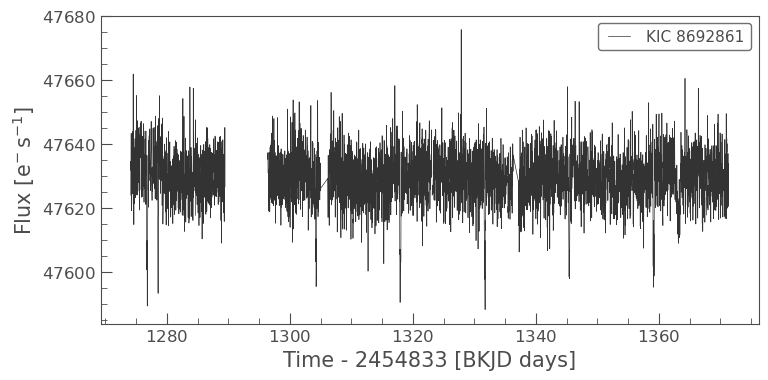

In [23]:
%matplotlib inline
klc.plot();

On this plot, the y-axis represents flux in electrons per second, and x-axis is time in Barycentric Kepler Julian Date (BKJD).

---

#### Identifying transiting exoplanet signals in a light curve using BLS
In order to identify transiting exoplanet signals in the light curve of Kepler-69, we download all available Kepler observations for this multi-planet system.

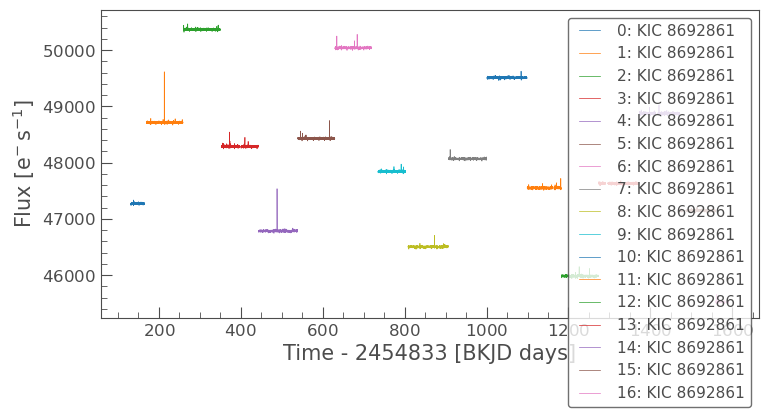

In [24]:
# Download all available Kepler light curves
lc_collection = search_result.download_all()
lc_collection.plot();

Here, each observation has a different offset. So, we should normalize and flatten the full observation. We should also combine multiple observations (quarters) to create a stitched light curve and successfully search for transits.

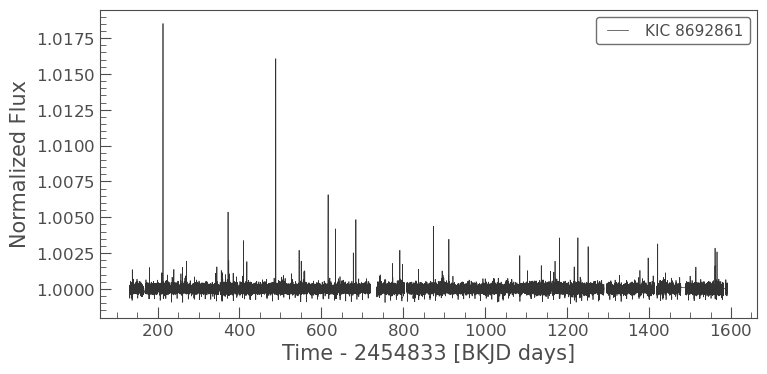

In [25]:
# Flatten the light curve
lcd = lc_collection.stitch().flatten(window_length=901)
lcd.plot();

The stitch() method is used to combine multiple light curve segments into a single, continuous light curve. The flatten() method is used to remove long-term trends or variations (low-frequency signals) from a light curve. The window_length is the size of the window for the Savitzky-Golay filter, which is used to smooth the light curve and estimate the trend to be removed. A smaller window length is sensitive to shorter-term trends, while a larger one captures longer-term variations. The goal is to isolate the short-term variations, such as transits, that are important in exoplanet detection studies.

To remove the outliers from the light curve, we can use remove_outliers() method.

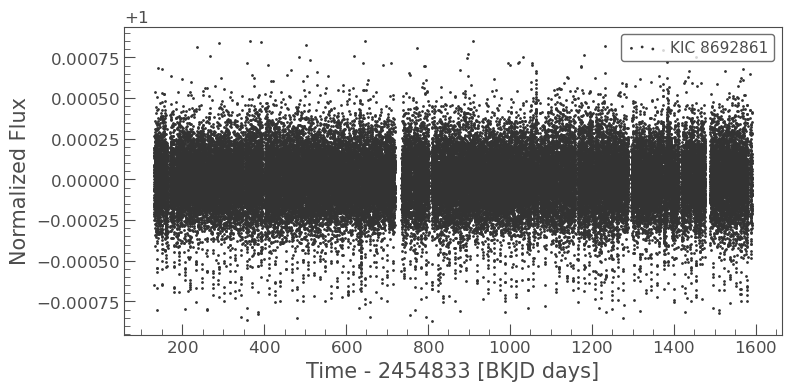

In [26]:
# Remove the outliers
lc = lcd.remove_outliers()
lc.scatter();

The [Box Least Squares](https://docs.astropy.org/en/stable/timeseries/bls.html) (BLS) periodogram analysis is the most common method used to identify transiting exoplanets. BLS uses an upside-down top hat with four parameters duration, period, depth, and reference time to model a transit. Then, these parameters are optimized by minimizing the square difference between the observed transit and the BLS transit model.
<div>
<img src="bls-1.png" width="500"/>
</div>

This method can optionally accept an array of periods (in days) to explore. We set it to range from 1 to 20 days, restricting our search to short-period exoplanets.

In [27]:
import numpy as np
# Create array of periods to search
period = np.linspace(1, 20, 10000) # The number of points to generate between 1 and 20 is 10,000.

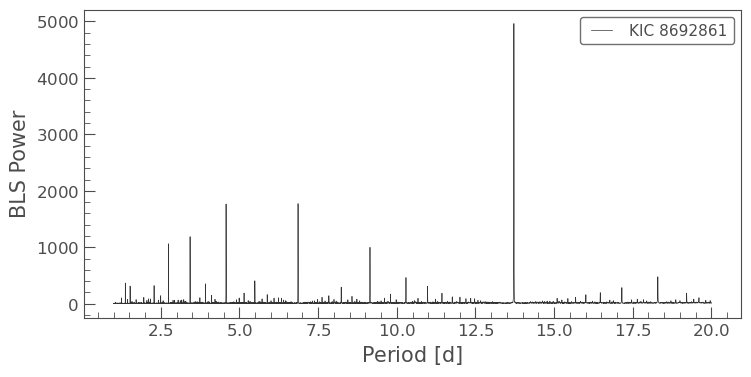

In [28]:
# Create a BLSPeriodogram
bls = lc.to_periodogram(method='bls', period=period, frequency_factor=500);
bls.plot();

This plot displays the BLS power (the likelihood of the BLS fit) for each of the periods in the period array. It shows several prominent peaks at specific periods, indicating a strong likelihood of detecting a transit. The tallest peak represents the most probable period. The most likely BLS parameters can be extracted by taking their values at maximum power. We call this transiting object 'planet b'.

In [29]:
planet_b_period = bls.period_at_max_power
planet_b_t0 = bls.transit_time_at_max_power
planet_b_duration = bls.duration_at_max_power
planet_b_depth = bls.depth_at_max_power

# Check the values
print(planet_b_period, planet_b_t0, planet_b_duration, planet_b_depth)

13.721772177217725 d 137.87216564080097 0.2 d 0.0004669015990524125


To verify that the identified period and transit time (epoch) correspond to a transit signal, we can phase-fold the light curve with these BLS parameters and visualize the result.

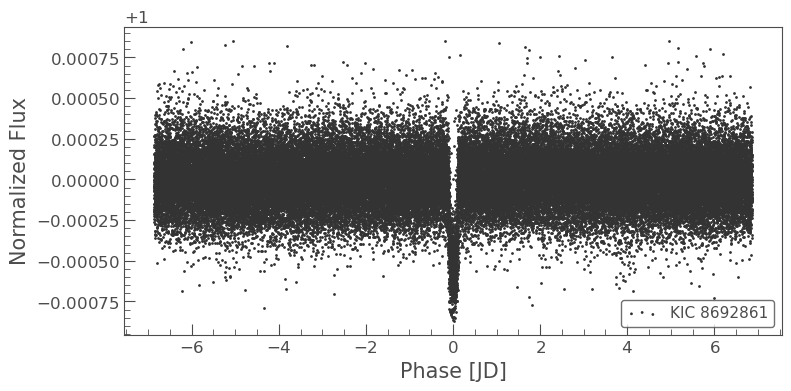

In [30]:
ax = lc.fold(period=planet_b_period, epoch_time=planet_b_t0).scatter()

We create the BLS model to visualize the transit fit and plot it over the folded light curve to confirm that it accurately represents the transit of planet b.

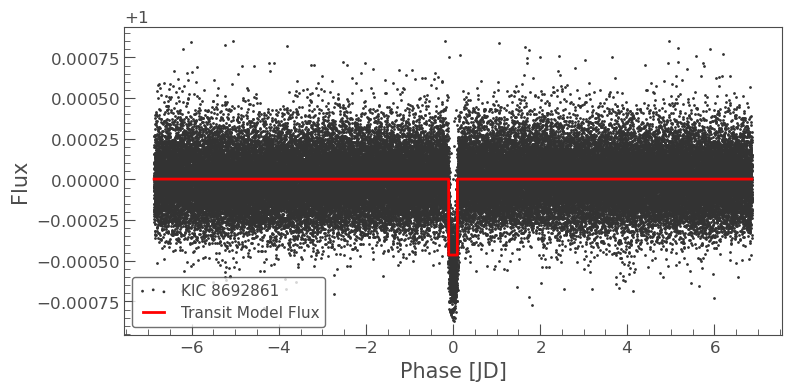

In [31]:
# Create the BLS model using the BLS parameters
planet_b_model = bls.get_transit_model(period=planet_b_period, transit_time=planet_b_t0, duration=planet_b_duration)
ax = lc.fold(planet_b_period, planet_b_t0).scatter()
planet_b_model.fold(planet_b_period, planet_b_t0).plot(ax=ax, c='r', lw=2);

Now, to identify additional transit signals, it is helpful to first remove the previously detected signal. This ensures that the strong periodicity of the first planet, planet b, does not dominate the BLS periodogram, making it easier to detect transits with lower signal-to-noise ratio (SNR).

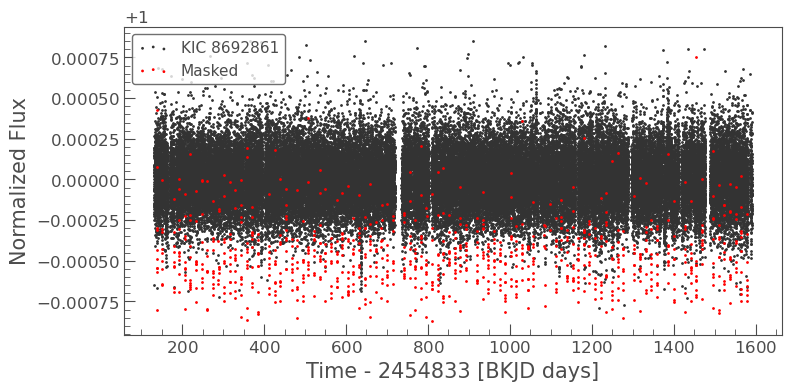

In [32]:
# Create a cadence mask using the BLS parameters
planet_b_mask = bls.get_transit_mask(period=planet_b_period, transit_time=planet_b_t0, duration=planet_b_duration)
masked_lc = lc[~planet_b_mask] # This selects all data points outside the transit windows, creating a masked light curve (masked_lc), where the transits of planet b are excluded.
ax = masked_lc.scatter();
lc[planet_b_mask].scatter(ax=ax, c='r', label='Masked');

In this graph, the red data points belong to the transits of planet b. By excluding them (masked_lc), the remaining light curve can be analyzed to search for additional transit signals from other planets. The black data points are the remaining data from Kepler-69.

With the light curve of the first identified exoplanet masked out, we can now examine the remaining data for additional transit signals. In this step, we expand the search range to include longer-period exoplanets, covering periods from 1 to 300 days.

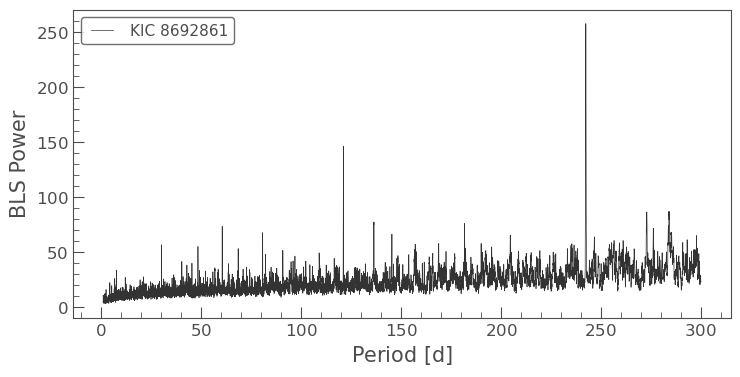

In [33]:
period = np.linspace(1, 300, 10000)
bls = masked_lc.to_periodogram('bls', period=period, frequency_factor=500)
bls.plot();

A clear peak is visible around 240 days. We can extract the associated period and transit time to analyze the signal further and plot the phase-folded light curve to examine the transit.

In [34]:
planet_c_period = bls.period_at_max_power
planet_c_t0 = bls.transit_time_at_max_power
planet_c_duration = bls.duration_at_max_power
planet_c_depth = bls.depth_at_max_power

# Check the values
print(planet_c_period, planet_c_t0, planet_c_duration, planet_c_depth)

242.46664666466646 d 150.83716564080095 0.33 d 0.0003305481095640188


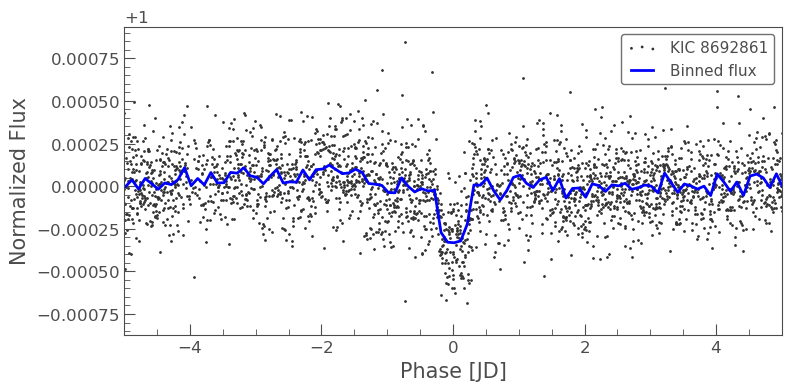

In [35]:
ax = masked_lc.fold(planet_c_period, planet_c_t0).scatter()
masked_lc.fold(planet_c_period, planet_c_t0).bin(0.1).plot(ax=ax, c='b', lw=2, label='Binned flux')
ax.set_xlim(-5, 5);

Here, the shallower transit depth indicates a smaller planet. This signal has a lower SNR, because the longer period results in fewer observed transits. To make the transit more visible, the data points have been binned with a width of 0.1 days (blue line).

Congratulations! We have identified two planets in this exoplanetary system. We can use the BLS models to visualize the transit timing in the light curve.

In [ ]:
# YOUR CODE HERE
# raise NotImplementedError()

## **Summary of Assignment A4**  

In this fourth assignment, we apply concepts from **Lecture 4** to real exoplanet light curve data. The focus is on downloading, processing, and analyzing light curves, using the **Box Least Squares (BLS) method** to detect potential exoplanet transits.  

### **Task 1: Data Exploration and Cleaning**  

1. **Examine the Kepler-10 Light Curve Data**  
   - Identify anomalies, missing values, and potential outliers in the dataset.  

2. **Develop a Function to Plot the Light Curve**  
   - Create a function to visualize **Flux vs. Time** for a better understanding of trends and noise levels.  

3. **Clean the Data**  
   - Handle missing values through **interpolation** or **removal of bad data points**.  
   - Detect and remove outliers to improve signal clarity.  

4. **Visualize Cleaned Light Curves**  
   - Use the **Lightkurve library** to generate high-quality plots.  
   - Compare raw vs. cleaned data to assess preprocessing effectiveness.  

This assignment reinforces **data preprocessing techniques** crucial for exoplanet detection and ensures reliable results when applying the **BLS method**. 

In [ ]:
# YOUR CODE HERE
# raise NotImplementedError()

# CNN

1. Prepare data from `exoTrain.csv` (train/validation/public split)
2. Apply simple preprocessing (normalize, Gaussian filter, scaling)
3. Train one basic 1D CNN
4. Report validation/public metrics and generate plots
5. Save final model as `student_model.joblib`

In [50]:
# Imports
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Import from preprocessor_class
from preprocessor_class import MyPreprocessor, CNNJoblibModel

warnings.filterwarnings('ignore')
np.random.seed(42)

# Lazy TensorFlow import:
# Importing TF can sometimes crash kernels in certain environments (e.g., GPU init).
# We will import TF only inside the CNN training / inference cells.
TF_AVAILABLE = False

In [52]:
# Load and prepare dataset (student-accessible only)
full_train_data = pd.read_csv('/home/yangz2/code/space_universe/Assign4/exoTrain.csv')
full_train_data['LABEL'] = full_train_data['LABEL'].map({1: 0, 2: 1})

X = full_train_data.drop(columns=['LABEL'])
y = full_train_data['LABEL'].astype(int)

# Student-visible split: train / validation / public test
X_train_raw, X_other_raw, y_train_raw, y_other_raw = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val_raw, X_public_raw, y_val, y_public = train_test_split(
    X_other_raw, y_other_raw, test_size=0.50, random_state=42, stratify=y_other_raw
)

print(f'Student train raw:   {len(X_train_raw)}')
print(f'Student val raw:     {len(X_val_raw)}')
print(f'Student public test: {len(X_public_raw)}')

Student train raw:   3560
Student val raw:     763
Student public test: 764


In [53]:
# Simple preprocessing (starter)
# Use MyPreprocessor from preprocessor_class.py

FEATURES = list(X_train_raw.columns)

# Try sigma=2 for less smoothing
preprocessor = MyPreprocessor.fit_from_training_df(
    X_train_raw,
    FEATURES,
    sigma=2.0  # Changed from 3.0 to 2.0
)

train_X_df = preprocessor.transform(X_train_raw)
val_X_df = preprocessor.transform(X_val_raw)
public_X_df = preprocessor.transform(X_public_raw)

train_X = train_X_df.to_numpy(dtype=np.float32)
val_X = val_X_df.to_numpy(dtype=np.float32)
X_public = public_X_df.to_numpy(dtype=np.float32)

train_y = y_train_raw.loc[train_X_df.index].to_numpy()
val_y = y_val.loc[val_X_df.index].to_numpy()
y_public_aligned = y_public.loc[public_X_df.index].to_numpy()

print(f'train_X: {train_X.shape}, train_y: {train_y.shape}')
print(f'val_X:   {val_X.shape}, val_y:   {val_y.shape}')
print(f'public_X:{X_public.shape}, y_public: {y_public_aligned.shape}')
print(f'Class distribution: {np.bincount(train_y)}')

train_X: (3560, 3197), train_y: (3560,)
val_X:   (763, 3197), val_y:   (763,)
public_X:(764, 3197), y_public: (764,)
Class distribution: [3534   26]


In [54]:
# Build and train one basic 1D CNN
import os as _os
_os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
_os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
_os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    from sklearn.utils.class_weight import compute_class_weight
except Exception as e:
    raise RuntimeError('TensorFlow is required for this CNN-only assignment notebook.') from e

# Force GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print(f"Using GPU: {gpus[0]}")
except Exception:
    pass

# Class weights for imbalance - more moderate
class_weight = {0: 1.0, 1: 5.0}  # Moderate weight instead of balanced
print("class_weight =", class_weight)

tf.keras.backend.clear_session()

time_steps = train_X.shape[1]

# Build deeper CNN model
model = models.Sequential([
    layers.Input(shape=(time_steps, 1)),
    
    # Block 1
    layers.Conv1D(64, kernel_size=7, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    # Block 2
    layers.Conv1D(128, kernel_size=5, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    # Block 3
    layers.Conv1D(256, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    
    # Block 4
    layers.Conv1D(512, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.4),
    
    # Dense
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

train_X_reshaped = train_X.reshape(-1, train_X.shape[1], 1)
val_X_reshaped = val_X.reshape(-1, val_X.shape[1], 1)
public_X_reshaped = X_public.reshape(-1, X_public.shape[1], 1)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    train_X_reshaped,
    train_y,
    epochs=40,  # More epochs
    batch_size=32,  # Smaller batch
    validation_data=(val_X_reshaped, val_y),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
class_weight = {0: 1.0, 1: 5.0}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3197, 64)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3197, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 3197, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1598, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1598, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1598, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1598, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 1598, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 799, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 799, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 799, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 799, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 799, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 399, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 399, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 399, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 399, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 399, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 607,553 (2.32 MB)

 Trainable params: 605,633 (2.31 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 42s 187ms/step - accuracy: 0.9868 - loss: 0.2441 - val_accuracy: 0.9934 - val_loss: 0.0394 - learning_rate: 5.0000e-04
Epoch 2/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9927 - loss: 0.1778 - val_accuracy: 0.9934 - val_loss: 0.0556 - learning_rate: 5.0000e-04
Epoch 3/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9927 - loss: 0.1738 - val_accuracy: 0.9934 - val_loss: 0.0331 - learning_rate: 5.0000e-04
Epoch 4/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9927 - loss: 0.1491 - val_accuracy: 0.9934 - val_loss: 0.0348 - learning_rate: 5.0000e-04
Epoch 5/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9927 - loss: 0.1434 - val_accuracy: 0.9934 - val_loss: 0.0331 - learning_rate: 5.0000e-04
Epoch 6/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9924 - loss: 0.1483 - val_accuracy: 0.9934 - val_loss: 0.0818 - learning_rate: 5.0000e-04
Epoch 7/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - a

In [ ]:
# Find best threshold on validation set
val_prob = model.predict(val_X_reshaped, verbose=0).ravel()

# More careful threshold search
thresholds = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(val_y, (val_prob >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = float(thresholds[best_idx])
best_f1 = f1_scores[best_idx]

print(f"Best threshold on validation = {best_threshold:.2f}")
print(f"Best validation F1 = {best_f1:.4f}")

# If validation F1 is too low, use lower threshold to ensure some positive predictions
if best_f1 < 0.15 or best_threshold > 0.4:
    best_threshold = 0.2
    print(f"Using aggressive threshold: {best_threshold}")

# Rebuild preprocessor from current file to avoid pickle issue
import importlib
import preprocessor_class as pc
importlib.reload(pc)
MyPreprocessorReloaded = pc.MyPreprocessor
CNNJoblibModelReloaded = pc.CNNJoblibModel

# Save bundle
TARGET = 'LABEL'

bundle = {
    'target': TARGET,
    'model': CNNJoblibModelReloaded(
        model.get_config(),
        model.get_weights(),
        threshold=best_threshold
    ),
    'preprocessor': MyPreprocessorReloaded(
        FEATURES,
        preprocessor.scaler_mean_,
        preprocessor.scaler_scale_,
        sigma=preprocessor.sigma
    ),
}

joblib.dump(bundle, 'student_model.joblib')
print('Saved student_model.joblib')

=== Validation Results ===
Validation Accuracy: 0.9934
Validation F1-score: 0.4444
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       758
           1       0.50      0.40      0.44         5

    accuracy                           0.99       763
   macro avg       0.75      0.70      0.72       763
weighted avg       0.99      0.99      0.99       763

=== Public Test Results ===
Public Accuracy: 0.9921
Public F1-score: 0.0000


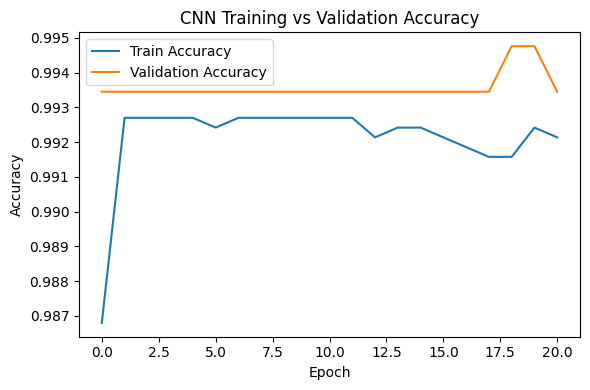

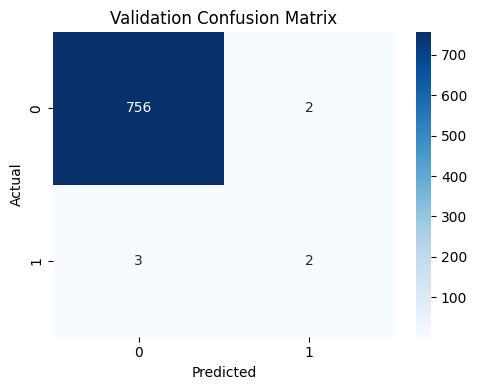

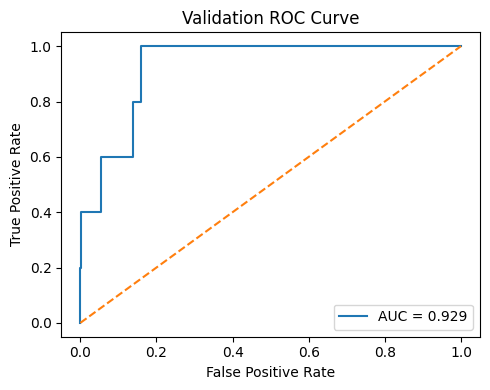

In [56]:
# Validate model and visualize results
val_pred = (val_prob >= best_threshold).astype(int)

public_prob = model.predict(public_X_reshaped, verbose=0).ravel()
public_pred = (public_prob >= best_threshold).astype(int)

print('=== Validation Results ===')
print(f'Validation Accuracy: {accuracy_score(val_y, val_pred):.4f}')
print(f'Validation F1-score: {f1_score(val_y, val_pred):.4f}')
print(classification_report(val_y, val_pred))

print('=== Public Test Results ===')
print(f'Public Accuracy: {accuracy_score(y_public_aligned, public_pred):.4f}')
print(f'Public F1-score: {f1_score(y_public_aligned, public_pred):.4f}')

# Accuracy plot
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix (validation)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(val_y, val_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC curve (validation)
fpr, tpr, _ = roc_curve(val_y, val_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

---
## Final Submission and Evaluation
Fill your details and run the next cell to generate `student_submission_metrics.csv`.

The private `exoTest.csv` evaluation is instructor-only and should be run outside the student notebook.

### What to do for submission

Before running the submission cell at the end of this notebook, make sure you:
- Train the CNN (above)
- Run the **bundle save** step so your submission contains `student_model.joblib` and `preprocessor_class.py`
- Fill in your `student_name` and `student_number`

Then this last cell will:
- Load your `student_model.joblib` bundle
- Compute public accuracy + F1 on the `exoTrain.csv` public split
- Save `student_submission_metrics.csv`


In [57]:
# STUDENT SUBMISSION CELL (student-visible, CNN-only)
student_name = 'Zeyu Yang'
student_number = '101513496'

student_model_path = 'student_model.joblib'

if not os.path.exists(student_model_path):
    raise FileNotFoundError('student_model.joblib not found. Train your CNN and save it as student_model.joblib')
if not os.path.exists('preprocessor_class.py'):
    raise FileNotFoundError('preprocessor_class.py not found. Run the bundle save step before submission.')

import importlib
import preprocessor_class
importlib.reload(preprocessor_class)
from preprocessor_class import MyPreprocessor, CNNJoblibModel
bundle = joblib.load(student_model_path)

student_model = bundle['model']
student_preprocessor = bundle['preprocessor']

# Use raw public-split features so preprocessing matches exactly what the grader will do
X_eval_df = X_public_raw.copy()
X_eval_processed = student_preprocessor.transform(X_eval_df)
y_eval_series = pd.Series(y_public).astype(int)

y_eval_aligned = y_eval_series.loc[X_eval_processed.index]

y_pred = student_model.predict(X_eval_processed)

acc = accuracy_score(y_eval_aligned, y_pred)
f1 = f1_score(y_eval_aligned, y_pred)

print('=== Student Public Evaluation Results (CNN / joblib bundle) ===')
print(f'Student name: {student_name}')
print(f'Student number: {student_number}')
print(f'Public Accuracy: {acc:.4f}')
print(f'Public F1-score: {f1:.4f}')
print('\nClassification report:')
print(classification_report(y_eval_aligned, y_pred))

submission = {
    'student_name': student_name,
    'student_number': student_number,
    'public_accuracy': float(acc),
    'public_f1': float(f1),
}

pd.DataFrame([submission]).to_csv('student_submission_metrics.csv', index=False)
print('\nSaved student_submission_metrics.csv')

=== Student Public Evaluation Results (CNN / joblib bundle) ===
Student name: Zeyu Yang
Student number: 101513496
Public Accuracy: 0.9921
Public F1-score: 0.0000

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       758
           1       0.00      0.00      0.00         6

    accuracy                           0.99       764
   macro avg       0.50      0.50      0.50       764
weighted avg       0.98      0.99      0.99       764


Saved student_submission_metrics.csv
